# Exhibit: The Forecasting Horserace

*Workshop 2 exhibit — **Structural Change and Expectations in Macroeconomics and Finance** (University of Copenhagen, Autumn 2026).*

## 1. The question: which model forecasts best?

Forecasting inflation is one of the oldest horseraces in empirical macroeconomics: line up competing forecasters, let them predict the same object in real time, and measure who comes closest. Our contestants:

1. **The naive random walk**: next year's inflation = the past year's. No model, no parameters, no estimation.
2. **A recursively estimated AR(1)**: a standard autoregressive model for quarterly inflation, re-estimated every quarter on **all data available so far** and iterated forward. This is the constant-parameter workhorse, applied exactly as the textbook logic says: *use all the information available, to get the best possible parameter estimates and the most precise out-of-sample forecasts.* More data, better estimates, better forecasts.
3. **The professional forecasters (SPF)**: models, data, and human judgment combined — the strongest opponent we can field.

All three obey the **real-time rule**: to forecast at quarter $t$, only data available through quarter $t$ may be used. The forecast target is the same object throughout: **average quarterly inflation over the next four quarters** — the Workshop 1 object.

### How the race is judged: RMSE

For each forecaster we collect the **forecast errors** over the evaluation sample — $e_{t+1} = \text{actual} - \text{forecast}$, one per quarter — and summarize them in a single number, the **root-mean-squared error**:

$$RMSE = \sqrt{\tfrac{1}{n} \textstyle\sum_t e_{t+1}^2}.$$

Read it as the forecaster's *typical miss*, in the same units as inflation: an RMSE of 1.3 means the forecasts are off by about 1.3 percentage points in a typical year. Two features of the formula matter:

- **Squaring before averaging makes large misses count more than small ones.** A forecaster who is usually close but occasionally disastrous is punished for the disasters — usually the right priority for forecast users, for whom the big misses are the costly ones.
- **The square root brings the number back to interpretable units**, so RMSEs can be compared directly: lower is better, and the *ratio* of two RMSEs says how much better — a ratio of 0.8 means a 20% smaller typical miss.

(RMSE is the standard yardstick but not the only one — the mean absolute error, for instance, weighs all misses equally. In this exhibit, RMSE is our judge.)

**Data:** quarterly US GDP-deflator inflation (first release) and the SPF, 1968–2024 — the Workshop 1 dataset. Evaluation sample: 1975Q1–2024Q2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLUE, RED, TEAL, GREY = "#006BA2", "#DB444B", "#3EBCD2", "#758D99"
ORANGE = "#EB8100"
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.alpha": 0.35,
    "axes.titlelocation": "left", "axes.titlesize": 12, "font.size": 11,
})

def load(name):
    try:
        df = pd.read_csv(f"../data/{name}", index_col="quarter")
    except FileNotFoundError:
        base = "https://raw.githubusercontent.com/mortentabor/structural-change-seminar/main/data/"
        df = pd.read_csv(base + name, index_col="quarter")
    df.index = pd.PeriodIndex(df.index, freq="Q")
    return df

pi = load("inflation_quarterly.csv")["inflation"]
fe = load("forecast_errors.csv").dropna(subset=["pi_avg", "F_avg", "pi_lag"])

## 2. Building the forecasts

The design splits the sample in two:

- **An initial estimation window.** A model needs data before it can forecast at all, so the first part of the sample — 1968Q4 through 1974Q4 — is reserved for the AR model's initial estimation and is never used for evaluation.
- **Recursive estimation over the remaining sample.** From 1975Q1 onward, at every quarter $t$ the AR(1) is **re-estimated on all data available through $t$** — the estimation window grows by one observation each quarter; that is what *recursive* means — and then iterated four quarters ahead to produce the forecast. The naive and SPF forecasts for the same quarters come straight from the Workshop 1 data.

Forecast errors — and hence every RMSE below — are computed **only over this remaining period, 1975Q1–2024Q2**: genuine out-of-sample, real-time forecasts throughout, never in-sample fit.

One helper does the model work: fit an AR(1) on whatever history it is given, iterate four quarters ahead, and average — so the AR forecaster predicts the same object as the SPF and the naive rule.

In [2]:
def ar1_forecast_avg(series):
    """Fit an AR(1) on `series`; iterate 4 steps ahead; return the average forecast."""
    y = series.values
    if len(y) < 8:
        return None
    X = np.column_stack([np.ones(len(y) - 1), y[:-1]])
    (c, phi), *_ = np.linalg.lstsq(X, y[1:], rcond=None)
    f, last = [], y[-1]
    for _ in range(4):
        last = c + phi * last
        f.append(last)
    return float(np.mean(f))

rows = []
for t in fe.index[fe.index >= "1975Q1"]:
    hist = pi.loc[:t].dropna()          # all information available at time t
    rows.append({
        "quarter": t,
        "actual": fe.loc[t, "pi_avg"],
        "ar": ar1_forecast_avg(hist),   # recursive: uses ALL past data, every quarter
        "naive": fe.loc[t, "pi_lag"],
        "spf": fe.loc[t, "F_avg"],
    })
fc = pd.DataFrame(rows).set_index("quarter").dropna()
print(f"Evaluation sample: {fc.index.min()}\u2013{fc.index.max()}  (n = {len(fc)})")
fc.tail(3).round(2)

Evaluation sample: 1975Q1–2024Q2  (n = 198)


,actual,ar,naive,spf
quarter,,,,
2023Q4,2.36,2.21,1.48,2.14
2024Q1,2.52,3.23,3.12,2.56
2024Q2,2.44,2.71,2.28,2.38


## 3. The full-sample verdict

In [3]:
def rmse(d, col):
    return float(np.sqrt(np.mean((d["actual"] - d[col]) ** 2)))

MODELS = ["ar", "naive", "spf"]
NAMES = {"ar": "Recursive AR(1)", "naive": "Naive rule", "spf": "Professional forecasters (SPF)",
         "ar_roll": "Rolling AR(1)"}

pd.DataFrame({"RMSE, 1975Q1\u20132024Q2 (pct. points)":
              {NAMES[m]: rmse(fc, m) for m in MODELS}}).round(2)

,"RMSE, 1975Q1–2024Q2 (pct. points)"
Recursive AR(1),1.36
Naive rule,1.28
Professional forecasters (SPF),1.00


A clear verdict, in two parts:

- **The professional forecasters win** — comfortably. Models, data, and judgment beat any single mechanical rule.
- Among the two mechanical rules, the **naive random walk beats the estimated AR model**. Fifty years of data, re-estimated every quarter with ever-greater precision — and it loses to “next year = past year.” **This corresponds to what Atkeson and Ohanian showed in an important 2001 paper**: for the US from the mid-1980s to the late 1990s, inflation forecasts from estimated models — including Phillips-curve models meant to embody our best structural knowledge — could not beat this naive rule. Our simple race reproduces their finding on a longer sample.

So: hang the medals, close the race? **One number per forecaster — a full-sample RMSE — silently assumes that relative performance is constant over the sample.** That is the same constant-parameter assumption we have been interrogating all along, now hiding inside the *evaluation* instead of the model.

Before testing it, look at the raw material behind each RMSE: the misses themselves, quarter by quarter.

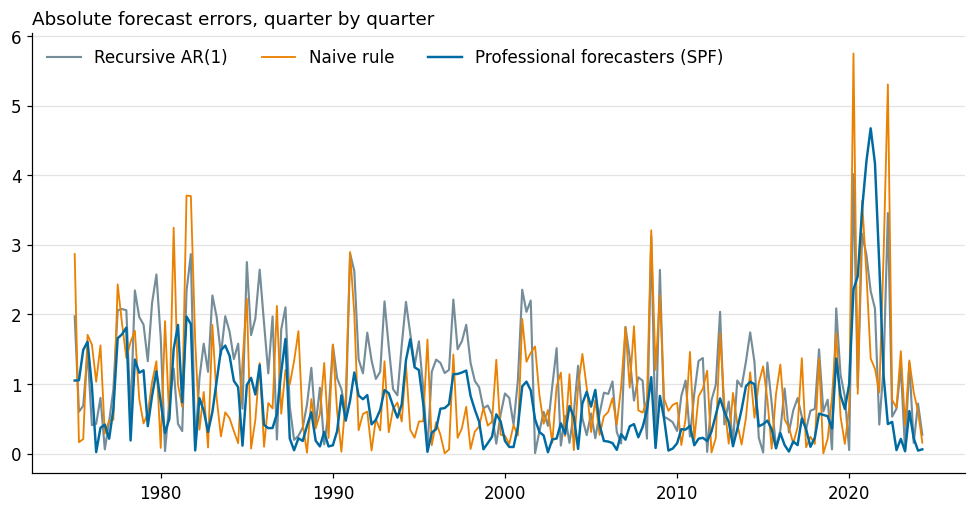

In [4]:
# The raw material of the RMSE: each forecaster's absolute error, quarter by quarter
styles = {"ar": (GREY, 1.4), "naive": (ORANGE, 1.2), "spf": (BLUE, 1.6)}
fig, ax = plt.subplots(figsize=(9, 4.8))
for m, (color, lw) in styles.items():
    ax.plot(fc.index.to_timestamp(), (fc["actual"] - fc[m]).abs(),
            color=color, lw=lw, label=NAMES[m])
ax.set_title("Absolute forecast errors, quarter by quarter")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

The misses are anything but evenly spread: every forecaster's errors **cluster in episodes** — the late 1970s and the post-2020 surge — with long quiet stretches between them. An average over all of it (the RMSE) blends those very different periods into one number.

## 4. Is the verdict stable?

Split the evaluation sample into eras and judge the race within each. **Change the eras** (edit the dictionary, rerun): does the winner depend on where you look?

In [5]:
ERAS = {
    "Full 1975\u20132024":  ("1975Q1", "2024Q2"),
    "1975\u20131979":       ("1975Q1", "1979Q4"),
    "Great Moderation":     ("1980Q1", "2019Q4"),
    "Post-2020":            ("2020Q1", "2024Q2"),
}

pd.DataFrame({era: {m: rmse(fc.loc[s:e], m) for m in MODELS}
              for era, (s, e) in ERAS.items()}).T.rename(columns=NAMES).round(2)

,Recursive AR(1),Naive rule,Professional forecasters (SPF)
Full 1975–2024,1.36,1.28,1.00
1975–1979,1.55,1.39,1.11
Great Moderation,1.27,1.07,0.72
Post-2020,1.87,2.37,2.26


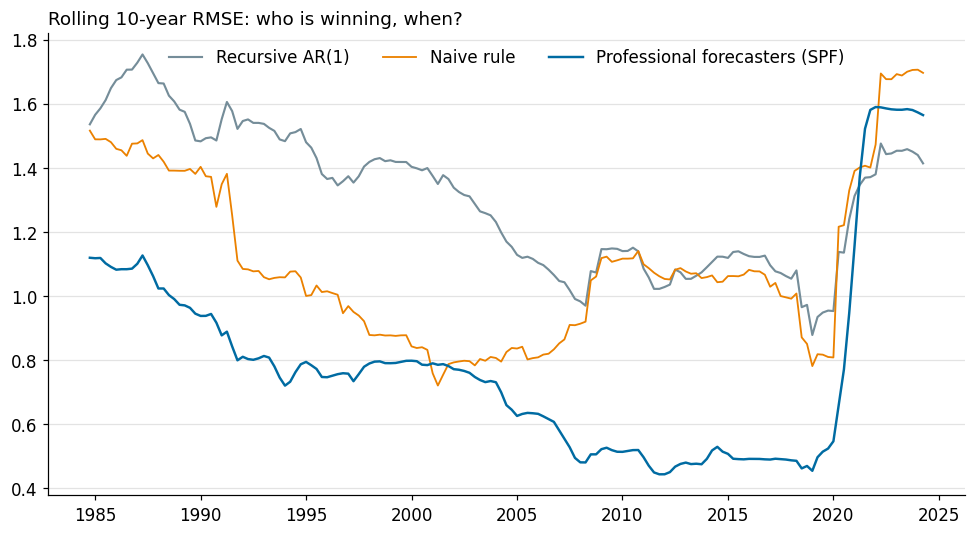

In [6]:
# The continuous view: rolling 10-year RMSE per forecaster
fig, ax = plt.subplots(figsize=(9, 5))
for m, (color, lw) in styles.items():
    r = (fc["actual"] - fc[m]).pow(2).rolling(40).mean().pow(0.5)
    ax.plot(fc.index.to_timestamp(), r, color=color, lw=lw, label=NAMES[m])
ax.set_title("Rolling 10-year RMSE: who is winning, when?")
ax.legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

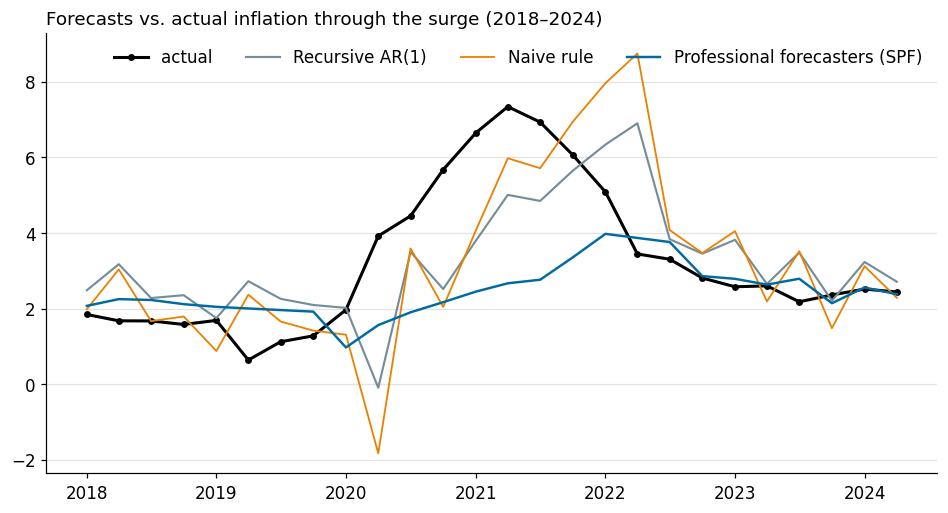

In [7]:
# Zoom: the forecasters through the post-2020 surge
zoom = fc.loc["2018Q1":]
fig, ax = plt.subplots(figsize=(9, 4.8))
x = zoom.index.to_timestamp()
ax.plot(x, zoom["actual"], color="black", lw=2, marker="o", ms=3.5, label="actual")
for m, (color, lw) in styles.items():
    ax.plot(x, zoom[m], color=color, lw=lw, label=NAMES[m])
ax.set_title("Forecasts vs. actual inflation through the surge (2018\u20132024)")
ax.legend(frameon=False, ncol=4)
plt.tight_layout()
plt.show()

The verdict is **not stable**:

- Through the **Great Moderation**, the full-sample ranking holds: the professionals dominate, the naive rule beats the AR.
- **Post-2020, the ranking turns upside down**: the AR model — the full-sample *loser* — is the best forecaster in the surge, **beating even the professionals**. Its long memory quietly insisted the spike would mean-revert; this time, it did.

So the question "which model forecasts best?" has no sample-independent answer — and a full-sample RMSE comparison answers it by *silently picking a sample*. This is precisely the problem studied by Rossi and Sekhposyan (2010) — who found that US forecasting models' relative performance changed dramatically over time — and by Giacomini and Rossi (2010), who built evaluation methods (fluctuation tests, the formal version of our rolling-RMSE plot) for exactly this situation.

## 5. A challenger built for change — does it settle the race?

If the world changes, an obvious fix suggests itself: **forget the old data**. Estimate the same AR(1) on a rolling window of the last 40 quarters, so the model always reflects the recent past. Surely *that* should dominate the constant-parameter version? Run it and see — and **try changing `WINDOW`** (20, then 60).

In [8]:
WINDOW = 40  # quarters — try 20, then 60

fc["ar_roll"] = [ar1_forecast_avg(pi.loc[:t].dropna().iloc[-WINDOW:]) for t in fc.index]
MODELS4 = ["ar", "ar_roll", "naive", "spf"]

pd.DataFrame({era: {m: rmse(fc.loc[s:e], m) for m in MODELS4}
              for era, (s, e) in ERAS.items()}).T.rename(columns=NAMES).round(2)

,Recursive AR(1),Rolling AR(1),Naive rule,Professional forecasters (SPF)
Full 1975–2024,1.36,1.33,1.28,1.00
1975–1979,1.55,1.54,1.39,1.11
Great Moderation,1.27,1.06,1.07,0.72
Post-2020,1.87,2.65,2.37,2.26


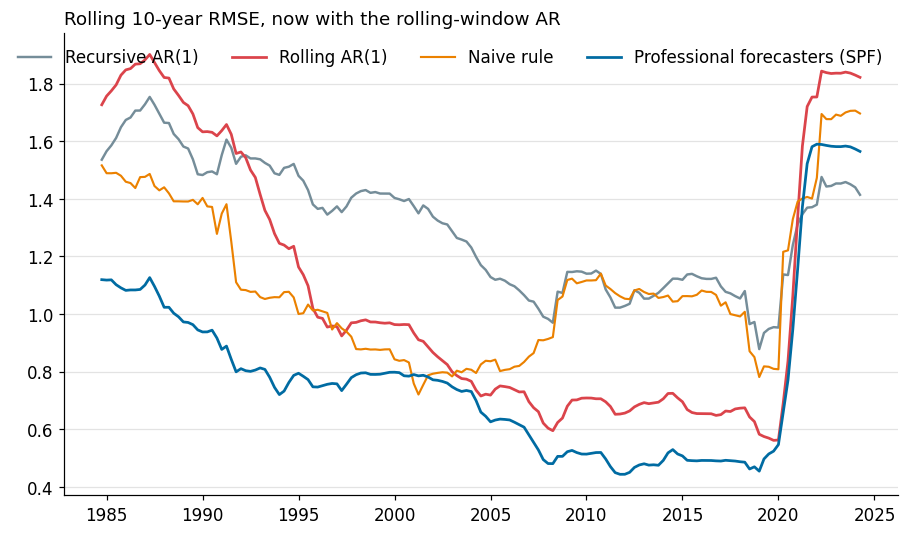

In [9]:
styles4 = {"ar": (GREY, 1.6), "ar_roll": (RED, 1.8), "naive": (ORANGE, 1.4), "spf": (BLUE, 1.8)}
fig, ax = plt.subplots(figsize=(9, 5))
for m, (color, lw) in styles4.items():
    r = (fc["actual"] - fc[m]).pow(2).rolling(40).mean().pow(0.5)
    ax.plot(fc.index.to_timestamp(), r, color=color, lw=lw, label=NAMES[m])
ax.set_title("Rolling 10-year RMSE, now with the rolling-window AR")
ax.legend(frameon=False, ncol=4)
plt.tight_layout()
plt.show()

Look at where the rolling model wins and where it loses. In our data it improves on the constant-parameter AR through the long stable decades — adapting pays when change is gradual — and then does *worst of all* in the surge, when its short window fills up with turbulent observations. But notice: **the lesson does not depend on how the rolling model happens to place.** Whether it wins an era or loses it, its arrival reshuffles the rankings *differently in different periods* — which is the finding itself:

**Forecast performance is not constant. There is no single best forecasting model — which forecaster wins depends on the period, and any single-number evaluation hides that.**

Which raises the real question — the one this seminar keeps arriving at from every direction: if the economy shifts, and no fixed model stays best, **how should a forecaster detect and account for structural change in real time?** Castle, Doornik and Hendry (2026) ask exactly this about the Bank of England's inflation forecasts through 2021–24 — could the mis-forecasts have been avoided with methods that capture a shift *as it happens*? That question — and the tools behind it — is where Workshop 3 begins.

## 6. What could a paper deliver?

You have now seen that forecast performance is not stable. **That, by itself, is not yet a research question.** Four types of questions you can build:

1. **Timing / episodes** — *when* do the rankings flip? Are the reversals concentrated at the same episodes where the SPF's errors turned systematic (Workshop 1)?
2. **Source / mechanism** — *why* does the constant-parameter AR win the surge: the mean-reversion assumption, the long memory, or luck? Decompose the errors.
3. **Interpretation / inference** — what is a forecast evaluation worth when rankings flip across regimes? What should replace the full-sample RMSE — and what do fluctuation-type methods (Giacomini and Rossi 2010) find in this data?
4. **Consequences / practice** — can *real-time* detection of shifts improve the forecasts — and would it have helped the Bank of England in 2021–24 (Castle, Doornik and Hendry 2026)? (A concrete tool you already know from Econometrics II: OxMetrics — its Autometrics algorithm can detect shifts automatically as data arrives. Building that into a forecasting exercise is a genuine, feasible seminar paper.)

**The "This paper…" exercise.** A research question is specific when you can state what the paper *delivers*:

> *Weak:* "This paper examines which model forecasts inflation best."
>
> *Strong:* "This paper shows that the ranking of standard inflation forecasters flipped in 2020 — the full-sample loser beat the professionals — and asks what an evaluation method must look like for a world where that can happen."

**Your task (in class):** write one or two **"This paper…"** sentences for this exhibit.

## 7. Further reading

If this exhibit grabbed you, start here:

- Rossi, B. (2021). "Forecasting in the Presence of Instabilities: How We Know Whether Models Predict Well and How to Improve Them." *Journal of Economic Literature*, 59(4) — the survey of exactly this exhibit's question.
- Rossi, B., and Sekhposyan, T. (2010). "Have Economic Models' Forecasting Performance for US Output Growth and Inflation Changed over Time, and When?" *International Journal of Forecasting*, 26(4) — this exhibit's story, done properly across many models.
- Giacomini, R., and Rossi, B. (2010). "Forecast Comparisons in Unstable Environments." *Journal of Applied Econometrics*, 25(4) — how to *evaluate* forecasts when relative performance shifts: the fluctuation test.
- Castle, J. L., Doornik, J. A., and Hendry, D. F. (2026). "Could the Bank of England Have Avoided Mis-forecasting UK Inflation during 2021–24?" *International Journal of Forecasting*, 42 — real-time structural change and a real central bank's forecast failure.
- Atkeson, A., and Ohanian, L. (2001). "Are Phillips Curves Useful for Forecasting Inflation?" *Federal Reserve Bank of Minneapolis Quarterly Review*, 25(1) — the classic naive-benchmark result our full-sample table reproduces.